In [7]:
import polars as pl

# 1. scan_csv를 사용하여 LazyFrame으로 시작 (메모리에 바로 안 올림)
# infer_schema_length는 0으로 두거나 적게 잡아서 속도를 높입니다.
q = pl.scan_csv('../data/raw/lending_club_2020_train.csv', 
                infer_schema_length=10000, 
                ignore_errors=True)

# ------------------------------------------------------------------
# 2. 필요한 컬럼만 선택 (메모리 절약의 핵심!)
# ------------------------------------------------------------------
# 일단 loan_status 분포만 볼 때는 다른 140개 컬럼이 필요 없습니다.
# 나중에 모델링할 때 필요한 변수들만 리스트에 추가해서 가져오면 됩니다.
q = q.select(['loan_status']) 

# ------------------------------------------------------------------
# 3. 기준 설정 (이전과 동일)
# ------------------------------------------------------------------
target_bad = ['Charged Off', 'Default', 'Late (31-120 days)']
target_good = ['Fully Paid']

# ------------------------------------------------------------------
# 4. 필터링 및 Target 생성 (Lazy 연산)
# ------------------------------------------------------------------
q_clean = (
    q.filter(pl.col('loan_status').is_in(target_bad + target_good))
     .with_columns(
         pl.when(pl.col('loan_status').is_in(target_bad))
         .then(1)
         .otherwise(0)
         .alias('target')
     )
)

# ------------------------------------------------------------------
# 5. collect()로 실행 (이때 실제 데이터가 메모리에 올라옴)
# ------------------------------------------------------------------
# 필터링이 된 상태로 가져오기 때문에 데이터 크기가 훨씬 줄어들어 있습니다.
df_clean = q_clean.collect()

print("작업 완료!")
print(f"정제 후 데이터 shape: {df_clean.shape}")

# 분포 확인
print("\n[최종 Target 분포]")
print(df_clean['target'].value_counts(sort=True))

# 비율 계산
total = df_clean.height
bad = df_clean.filter(pl.col('target') == 1).height
print(f"\n부도 비율: {bad / total * 100:.2f}%")

작업 완료!
정제 후 데이터 shape: (1125996, 2)

[최종 Target 분포]
shape: (2, 2)
┌────────┬────────┐
│ target ┆ count  │
│ ---    ┆ ---    │
│ i32    ┆ u32    │
╞════════╪════════╡
│ 0      ┆ 898522 │
│ 1      ┆ 227474 │
└────────┴────────┘

부도 비율: 20.20%


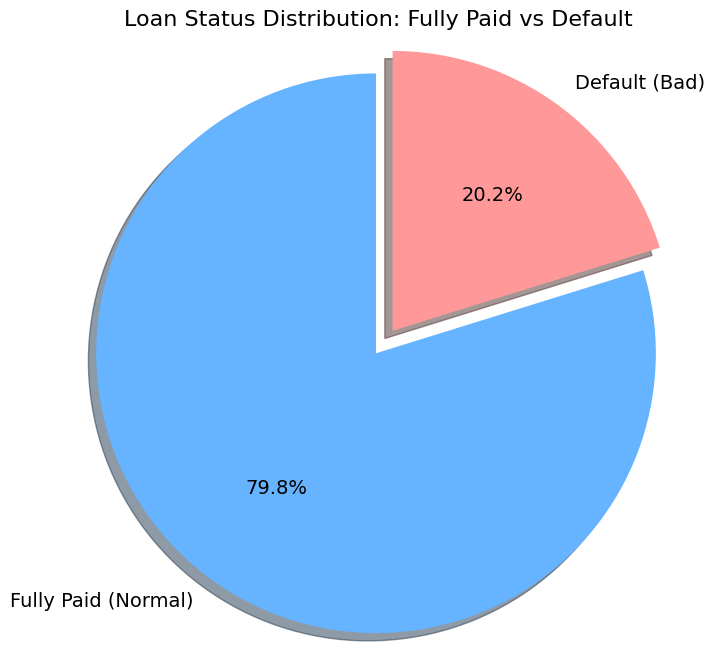

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 타겟 값 카운트 (Polars)
target_counts = df_clean['target'].value_counts(sort=True)

# 2. 데이터 준비 for Plotting
# Polars DataFrame을 리스트로 변환하거나 바로 접근
labels = ['Fully Paid (Normal)', 'Default (Bad)']
# 0이 정상, 1이 부도이므로 순서에 맞게 개수 추출
# (value_counts 결과가 정렬되어 있다고 가정하되, 안전하게 필터링해서 카운트)
count_0 = df_clean.filter(pl.col('target') == 0).height
count_1 = df_clean.filter(pl.col('target') == 1).height
sizes = [count_0, count_1]

# 3. 색상 설정 (파랑: 정상, 빨강: 부도)
colors = ['#66b3ff', '#ff9999']
explode = (0, 0.1)  # 부도(Bad) 부분만 살짝 떼어내서 강조

# 4. 시각화
plt.figure(figsize=(8, 8))
plt.pie(sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors, 
        autopct='%1.1f%%',  # 소수점 첫째 자리까지 % 표시
        shadow=True, 
        startangle=90,      # 90도에서 시작 (모양 예쁘게)
        textprops={'fontsize': 14}) # 글자 크기 키움

plt.title('Loan Status Distribution: Fully Paid vs Default', fontsize=16)
plt.axis('equal')  # 원을 동그랗게 유지
plt.show()

1단계: 유출 변수 제거 및 Base 데이터 저장
먼저, 분석표에서 "삭제/유출"로 판단된 변수들을 제거하고, loan_status를 0과 1로 변환하여 저장합니다. (살려야 한다고 결론 내린 funded_amnt, initial_list_status 등은 제거 리스트에서 뺐습니다.)

In [9]:
import polars as pl
import os

# 1. 데이터 로드 (Lazy)
q = pl.scan_csv('../data/raw/lending_club_2020_train.csv', 
                infer_schema_length=10000, 
                ignore_errors=True)

# 2. Target 정의 (부도=1, 정상=0)
target_bad = ['Charged Off', 'Default', 'Late (31-120 days)']
target_good = ['Fully Paid'] # Current 등은 제거

q_clean = (
    q.filter(pl.col('loan_status').is_in(target_bad + target_good))
     .with_columns(
         pl.when(pl.col('loan_status').is_in(target_bad))
         .then(1)
         .otherwise(0)
         .alias('target')
     )
)

# 3. 제거할 변수 리스트 (분석표 기반 유출 및 불필요 변수)
# 주의: funded_amnt, initial_list_status, fico_range_high 등은 살려둠!
drop_cols = [
    # [Data Leakage] 미래 시점 정보
    'recoveries', 'collection_recovery_fee', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_d', 
    'last_pymnt_amnt', 'next_pymnt_d', 'total_pymnt', 'total_pymnt_inv',
    'debt_settlement_flag', 'settlement_status', 'settlement_date', 
    'settlement_amount', 'settlement_percentage', 'settlement_term',
    'last_fico_range_high', 'last_fico_range_low', 
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 'out_prncp', 'out_prncp_inv', 
    'pymnt_plan', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths',

    # [Useless/ID] 식별자 및 텍스트, 기타
    'url', 'id', 'member_id', 'policy_code', 'zip_code', 
    'emp_title', 'title', 'loan_status', # 원본 loan_status는 target으로 변환했으니 삭제
    'funded_amnt_inv', # 투자 모집 금액은 삭제 (funded_amnt만 사용)
    
    # [Joint App 관련] 통합 변수 생성 후 삭제할 것이므로 일단 둠 (Step 2에서 처리)
    # 'sec_app_...' 등은 일단 가져갑니다.
]

# 4. 실행 및 저장
print("데이터 정제 중...")
df = q_clean.collect()

# 존재하는 컬럼만 삭제
real_drop_cols = [c for c in drop_cols if c in df.columns]
df_base = df.drop(real_drop_cols)

# 저장
save_dir = '../data/processed'
os.makedirs(save_dir, exist_ok=True)
save_path_base = os.path.join(save_dir, 'train_no_leakage.parquet')

df_base.write_parquet(save_path_base, compression='snappy')
print(f"✅ 1단계 완료: {save_path_base}")
print(f"남은 변수 개수: {len(df_base.columns)}")

데이터 정제 중...


✅ 1단계 완료: ../data/processed/train_no_leakage.parquet
남은 변수 개수: 101


In [10]:
# ------------------------------------------------------------------
# 제거된 변수 목록 정리해서 출력
# ------------------------------------------------------------------

# 실제 제거된 컬럼
removed_cols = [c for c in drop_cols if c in df.columns]

# 카테고리별 분류 (drop_cols 정의 그대로 의미 유지)
leakage_cols = [
    'recoveries', 'collection_recovery_fee', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_d', 
    'last_pymnt_amnt', 'next_pymnt_d', 'total_pymnt', 'total_pymnt_inv',
    'last_fico_range_high', 'last_fico_range_low',
    'out_prncp', 'out_prncp_inv'
]

hardship_cols = [
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount'
]

settlement_cols = [
    'debt_settlement_flag', 'settlement_status', 'settlement_date',
    'settlement_amount', 'settlement_percentage', 'settlement_term'
]

id_text_cols = [
    'url', 'id', 'member_id', 'policy_code', 'zip_code',
    'emp_title', 'title'
]

target_related_cols = ['loan_status']

other_cols = [
    'funded_amnt_inv', 'pymnt_plan', 
    'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

def print_group(title, cols):
    cols = [c for c in cols if c in removed_cols]
    if cols:
        print(f"\n[{title}] ({len(cols)}개)")
        for c in sorted(cols):
            print(f"  - {c}")

print("\n================ 제거된 변수 요약 ================")
print_group("Data Leakage (미래 정보)", leakage_cols)
print_group("Hardship / 구제 프로그램", hardship_cols)
print_group("채무 조정 / 합의(Settlement)", settlement_cols)
print_group("식별자 / 텍스트(ID·설명용)", id_text_cols)
print_group("Target 파생으로 제거", target_related_cols)
print_group("기타 의미 없거나 중복", other_cols)

print("\n[총 제거된 변수 수]", len(removed_cols))
print("=================================================")



================ 제거된 변수 요약 ================

[Data Leakage (미래 정보)] (14개)
  - collection_recovery_fee
  - last_fico_range_high
  - last_fico_range_low
  - last_pymnt_amnt
  - last_pymnt_d
  - next_pymnt_d
  - out_prncp
  - out_prncp_inv
  - recoveries
  - total_pymnt
  - total_pymnt_inv
  - total_rec_int
  - total_rec_late_fee
  - total_rec_prncp

[Hardship / 구제 프로그램] (14개)
  - hardship_amount
  - hardship_dpd
  - hardship_end_date
  - hardship_flag
  - hardship_last_payment_amount
  - hardship_length
  - hardship_loan_status
  - hardship_payoff_balance_amount
  - hardship_reason
  - hardship_start_date
  - hardship_status
  - hardship_type
  - orig_projected_additional_accrued_interest
  - payment_plan_start_date

[채무 조정 / 합의(Settlement)] (1개)
  - debt_settlement_flag

[식별자 / 텍스트(ID·설명용)] (6개)
  - emp_title
  - id
  - policy_code
  - title
  - url
  - zip_code

[Target 파생으로 제거] (1개)
  - loan_status

[기타 의미 없거나 중복] (5개)
  - chargeoff_within_12_mths
  - funded_amnt_inv
  - num_tl_120dp

In [ ]:
# ------------------------------------------------------------------
# 남은 변수 목록 정리해서 출력
# ------------------------------------------------------------------

remaining_cols = df_base.columns

# 카테고리별 분류 (Lending Club 표준 기준)
basic_loan_cols = [
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'issue_d'
]

borrower_cols = [
    'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'addr_state'
]

credit_profile_cols = [
    'fico_range_low', 'fico_range_high', 'earliest_cr_line',
    'open_acc', 'total_acc', 'mort_acc'
]

credit_behavior_cols = [
    'revol_bal', 'revol_util', 'dti', 'delinq_2yrs',
    'inq_last_6mths', 'pub_rec', 'pub_rec_bankruptcies'
]

history_mths_cols = [c for c in remaining_cols if 'mths_since' in c]

joint_app_cols = [c for c in remaining_cols if c.startswith('sec_app_') or c.endswith('_joint')]

other_cols = [
    c for c in remaining_cols
    if c not in (
        basic_loan_cols + borrower_cols + credit_profile_cols +
        credit_behavior_cols + history_mths_cols + joint_app_cols + ['target']
    )
]

def print_group(title, cols):
    cols = [c for c in cols if c in remaining_cols]
    if cols:
        print(f"\n[{title}] ({len(cols)}개)")
        for c in sorted(cols):
            print(f"  - {c}")

print("\n================ 남은 변수 요약 ================")
print_group("대출 기본 정보", basic_loan_cols)
print_group("차주 정보", borrower_cols)
print_group("신용 프로파일", credit_profile_cols)
print_group("신용 행태 / 사용량", credit_behavior_cols)
print_group("mths_since 계열", history_mths_cols)
print_group("Joint App 관련", joint_app_cols)
print_group("기타", other_cols)

print("\n[Target]")
print("  - target")

print("\n[총 남은 변수 수]", len(remaining_cols))
print("==============================================")



================ 남은 변수 요약 ================

[대출 기본 정보] (8개)
  - funded_amnt
  - grade
  - installment
  - int_rate
  - issue_d
  - loan_amnt
  - sub_grade
  - term

[차주 정보] (6개)
  - addr_state
  - annual_inc
  - emp_length
  - home_ownership
  - purpose
  - verification_status

[신용 프로파일] (6개)
  - earliest_cr_line
  - fico_range_high
  - fico_range_low
  - mort_acc
  - open_acc
  - total_acc

[신용 행태 / 사용량] (7개)
  - delinq_2yrs
  - dti
  - inq_last_6mths
  - pub_rec
  - pub_rec_bankruptcies
  - revol_bal
  - revol_util

[mths_since 계열] (8개)
  - mths_since_last_delinq
  - mths_since_last_major_derog
  - mths_since_last_record
  - mths_since_rcnt_il
  - mths_since_recent_bc
  - mths_since_recent_bc_dlq
  - mths_since_recent_inq
  - mths_since_recent_revol_delinq

[Joint App 관련] (15개)
  - annual_inc_joint
  - dti_joint
  - revol_bal_joint
  - sec_app_chargeoff_within_12_mths
  - sec_app_collections_12_mths_ex_med
  - sec_app_earliest_cr_line
  - sec_app_fico_range_high
  - sec_app_fico_ran

: 

2단계: 통합 변수 생성 및 결측치 처리 (Feature Engineering)
이제 저장된 데이터를 불러와서 "Joint App 정보를 합치고", "mths_since 변수에 9999를 채우는" 핵심 작업을 수행합니다.

In [ ]:
# 1. 정제된 데이터 로드
df = pl.read_parquet('../data/processed/train_no_leakage.parquet')

print("Feature Engineering 시작...")

# ------------------------------------------------------------------
# A. 통합 변수(Unified Features) 생성
# "Joint App이면 joint 값을 쓰고, 아니면 개인 값을 쓴다"
# ------------------------------------------------------------------
df_featured = df.with_columns([
    # 1. 통합 연소득 (effective_annual_inc)
    # annual_inc_joint가 null이 아니면 그거 쓰고, null이면 annual_inc 씀
    pl.coalesce([pl.col('annual_inc_joint'), pl.col('annual_inc')]).alias('effective_annual_inc'),

    # 2. 통합 DTI (effective_dti)
    pl.coalesce([pl.col('dti_joint'), pl.col('dti')]).alias('effective_dti'),
    
    # 3. 통합 검증 상태 (effective_verification)
    pl.coalesce([pl.col('verification_status_joint'), pl.col('verification_status')]).alias('effective_verification')
])

# ------------------------------------------------------------------
# B. 결측치 처리 (Imputation)
# "사건이 발생한 적 없음"을 의미하는 NaN -> 9999로 채우기
# ------------------------------------------------------------------
# mths_since 계열 변수 찾기
mths_cols = [c for c in df.columns if 'mths_since' in c]
print(f"9999로 채울 변수들: {mths_cols}")

# 해당 변수들의 null을 9999로 채움 (Tree 모델이 분기할 수 있도록)
df_featured = df_featured.with_columns([
    pl.col(c).fill_null(9999) for c in mths_cols
])

# 추가: 연체 횟수 등이 Null인 경우 -> 0회로 간주 (분석표 내용 반영)
count_vars = ['pub_rec_bankruptcies', 'tax_liens', 'collections_12_mths_ex_med']
existing_count_vars = [c for c in count_vars if c in df.columns]
df_featured = df_featured.with_columns([
    pl.col(c).fill_null(0) for c in existing_count_vars
])

# ------------------------------------------------------------------
# C. 날짜 파생변수 생성 (Credit History Length)
# ------------------------------------------------------------------
# 문자열(Str) -> 날짜(Date) 변환
# Lending Club 날짜 형식: "Apr-2019" (%b-%Y)
df_featured = df_featured.with_columns([
    pl.col('issue_d').str.strptime(pl.Date, '%b-%Y', strict=False).alias('issue_d_parsed'),
    pl.col('earliest_cr_line').str.strptime(pl.Date, '%b-%Y', strict=False).alias('earliest_cr_line_parsed')
])

# 신용 이력 기간 계산 (대출 실행일 - 최초 신용 개설일) -> 연 단위 변환
# 날짜가 null인 경우를 대비해 fill_null 처리 필요할 수 있음
df_featured = df_featured.with_columns(
    ((pl.col('issue_d_parsed') - pl.col('earliest_cr_line_parsed')).dt.total_days() / 365.25).alias('credit_hist_years')
)

# ------------------------------------------------------------------
# D. 사용 완료한 원본 변수 및 잉여 변수 제거
# ------------------------------------------------------------------
cols_to_remove = [
    # 통합되었으므로 원본 삭제
    'annual_inc', 'annual_inc_joint', 
    'dti', 'dti_joint', 
    'verification_status', 'verification_status_joint',
    
    # 날짜 파싱했으므로 원본 문자열 삭제
    'issue_d', 'earliest_cr_line',
    
    # Joint App 관련 나머지 변수들 (너무 결측 많고 복잡하면 일단 삭제 추천)
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 
    'sec_app_collections_12_mths_ex_med'
]

real_remove_cols = [c for c in cols_to_remove if c in df_featured.columns]
df_final = df_featured.drop(real_remove_cols)

# ------------------------------------------------------------------
# E. 최종 저장
# ------------------------------------------------------------------
save_path_final = os.path.join(save_dir, 'train_featured.parquet')
df_final.write_parquet(save_path_final, compression='snappy')

print("-" * 30)
print(f"✅ 2단계 완료: {save_path_final}")
print(f"최종 변수 개수: {len(df_final.columns)}")
print("생성된 변수 예시:", ['effective_dti', 'credit_hist_years'])

In [2]:
num_cols = [c for c, t in df_final.schema.items() if t != pl.Utf8]
cat_cols = [c for c, t in df_final.schema.items() if t == pl.Utf8]

print("Numeric columns:")
print(num_cols)
print("\nCategorical columns:")
print(cat_cols)


NameError: name 'df_final' is not defined

In [5]:
print("Numeric columns:")
for c in num_cols:
    print(f"  - {c}")

print("\nCategorical columns:")
for c in cat_cols:
    print(f"  - {c}")


Numeric columns:


NameError: name 'num_cols' is not defined

In [3]:
import polars as pl
import os

# 1. Feature Engineering이 끝난 데이터 로드
df = pl.read_parquet('../data/processed/train_featured.parquet')

print(f"로드된 데이터: {df.shape}")

# ------------------------------------------------------------------
# 1. Ordinal Encoding (순서가 중요한 변수)
# ------------------------------------------------------------------
# grade와 sub_grade는 신용 등급이므로 순서가 중요합니다.
# A1이 제일 좋고(0), G5가 제일 나쁨(34) -> 이렇게 숫자로 매핑해야 모델이 이해합니다.

# sub_grade 고유값 정렬 (A1, A2, ... G5 순서대로)
# Lending Club 데이터 특성상 알파벳+숫자 조합이므로 사전순 정렬하면 정확히 위험도 순서가 됩니다.
sub_grade_order = sorted(df['sub_grade'].unique().to_list())
sub_grade_map = {grade: i for i, grade in enumerate(sub_grade_order)}

# grade 매핑 (A=0, B=1, ...)
grade_order = sorted(df['grade'].unique().to_list())
grade_map = {grade: i for i, grade in enumerate(grade_order)}

# 매핑 적용 (replace 사용)
# 주의: Polars 최신 버전에 따라 replace 문법이 다를 수 있어 map_dict 사용 권장
df_encoded = df.with_columns([
    pl.col('sub_grade').replace(sub_grade_map).alias('sub_grade_num'),
    pl.col('grade').replace(grade_map).alias('grade_num')
])

print("✅ Grade/Sub_grade 인코딩 완료")

# ------------------------------------------------------------------
# 2. One-Hot Encoding (명목형 변수)
# ------------------------------------------------------------------
# 순서가 없는 카테고리들입니다.
# home_ownership, verification_status(통합된 것), purpose, addr_state, initial_list_status
cat_cols = [
    'home_ownership', 
    'effective_verification', # 아까 만든 통합 변수
    'purpose', 
    'initial_list_status',
    'application_type' # Individual / Joint App 구분용
]

# addr_state는 주(State)가 50개라 One-Hot 하면 컬럼이 50개 늘어납니다.
# 차원을 너무 늘리기 싫다면 일단 제외하거나, Target Encoding을 나중에 적용해도 됩니다.
# 여기서는 일단 포함하겠습니다.
if 'addr_state' in df.columns:
    cat_cols.append('addr_state')

# One-Hot Encoding 수행
df_encoded = df_encoded.to_dummies(cat_cols)

print(f"✅ One-Hot Encoding 완료. (컬럼 수 증가: {len(df.columns)} -> {len(df_encoded.columns)})")

# ------------------------------------------------------------------
# 3. 문자열 원본 컬럼 제거 및 정리
# ------------------------------------------------------------------
# 인코딩된 원본 문자열 컬럼과 학습에 필요 없는 문자열 컬럼 제거
cols_to_drop = [
    'grade', 'sub_grade', # 숫자로 바꿨으니 제거
    'issue_d_parsed', 'earliest_cr_line_parsed' # 날짜 계산 했으니 제거 (또는 남겨둬도 됨)
]

# to_dummies를 하면 원본 컬럼은 자동으로 사라지거나 남을 수 있는데(설정에 따라),
# Polars to_dummies는 원본을 제거하고 생성합니다.
# 따라서 grade/sub_grade와 날짜 컬럼만 지워주면 됩니다.

real_drop = [c for c in cols_to_drop if c in df_encoded.columns]
df_final_ready = df_encoded.drop(real_drop)

# ------------------------------------------------------------------
# 4. 최종 저장 (모델링용 데이터)
# ------------------------------------------------------------------
save_path = '../data/processed/train_final_ready.parquet'
df_final_ready.write_parquet(save_path, compression='snappy')

print("-" * 30)
print(f"🎉 모든 전처리 완료! 저장됨: {save_path}")
print(f"최종 데이터 Shape: {df_final_ready.shape}")
print("이제 03_modeling.ipynb 에서 바로 학습(Fit) 가능합니다!")

로드된 데이터: (1125996, 87)
✅ Grade/Sub_grade 인코딩 완료
✅ One-Hot Encoding 완료. (컬럼 수 증가: 87 -> 161)
------------------------------
🎉 모든 전처리 완료! 저장됨: ../data/processed/train_final_ready.parquet
최종 데이터 Shape: (1125996, 157)
이제 03_modeling.ipynb 에서 바로 학습(Fit) 가능합니다!


In [ ]:
# 문자열(String) 컬럼이 남아있는지 확인
print(df_final_ready.select(pl.col(pl.Utf8)).columns)
# 빈 리스트 [] 가 나오면 성공!

['term', 'int_rate', 'emp_length', 'revol_util', 'last_credit_pull_d', 'sub_grade_num', 'grade_num']


: 